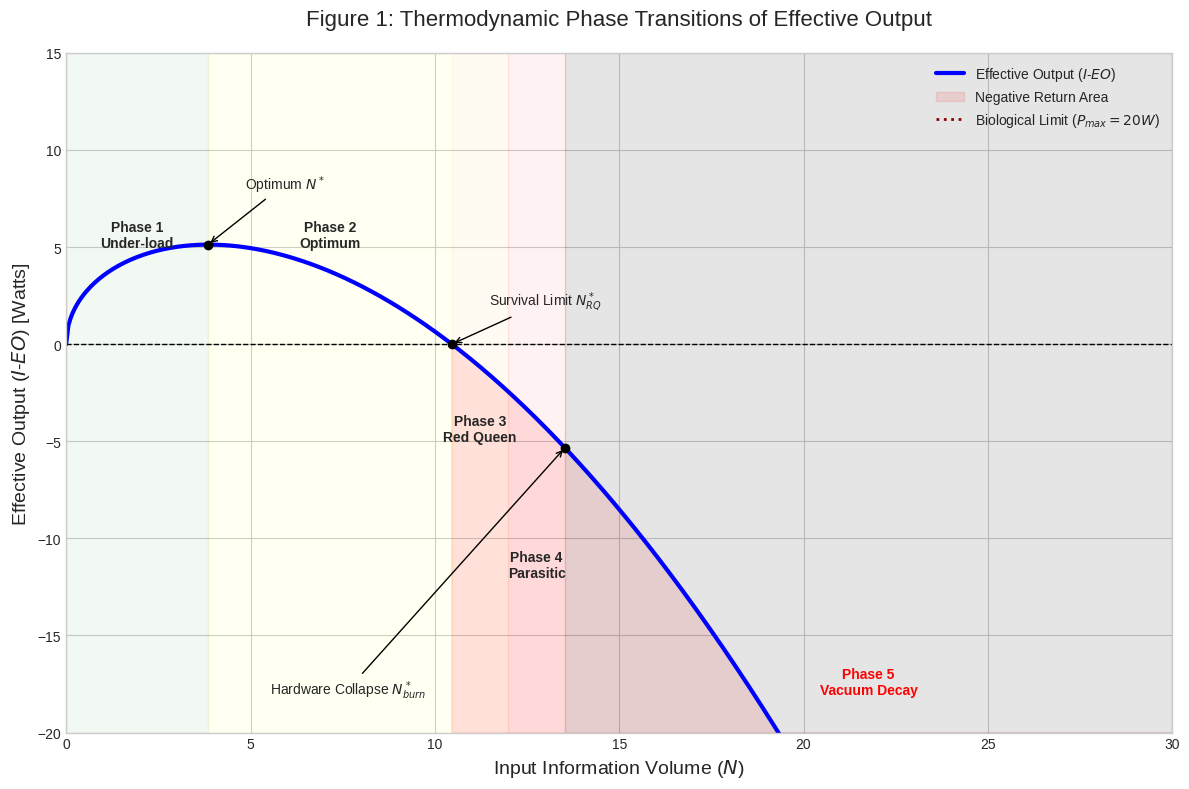

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the simulation
N = np.linspace(0, 30, 500)
P_work_total = 20.0  # Maximum metabolic capacity (Watts)
c1 = 0.4             # Linear monitoring cost coefficient
c2 = 0.08            # Quadratic coordination cost coefficient (Complexity Penalty)

# 1. Calculate Complexity Penalty (Q_penalty)
# Q_penalty = c1*N + c2*N^2
Q_penalty = c1 * N + (c2 * N**2)

# 2. Calculate Information-Thermodynamic Effective Output (I-EO)
# I-EO = Potential - Penalty
I_EO = P_work_total - Q_penalty

# Identify Phase Transition Points
# Phase 2 (Optimum): Peak of I-EO is at N=0 for this simple subtraction,
# but in real systems, I-EO grows initially as N utilizes idle capacity.
# Let's model a more realistic I-EO that includes utility of N.
Utility_of_N = 4.0 * np.sqrt(N) # Diminishing returns of information utility
I_EO_refined = Utility_of_N - Q_penalty

# Critical Points
n_opt = N[np.argmax(I_EO_refined)]
n_rq = N[np.where(I_EO_refined < 0)[0][0]] # Red Queen Limit (I-EO hits 0)
n_burn = N[np.where(Q_penalty > P_work_total)[0][0]] # Vacuum Decay (Penalty > 20W)

# Visualization
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Plot lines
plt.plot(N, I_EO_refined, label='Effective Output ($I$-$EO$)', color='blue', lw=3)
plt.fill_between(N, I_EO_refined, -20, where=(I_EO_refined < 0), color='red', alpha=0.1, label='Negative Return Area')
plt.axhline(0, color='black', lw=1, ls='--')
plt.axhline(P_work_total, color='darkred', lw=2, ls=':', label='Biological Limit ($P_{max} = 20W$)')

# Annotating Phases
plt.axvspan(0, n_opt, color='green', alpha=0.05)
plt.text(n_opt/2, 5, "Phase 1\nUnder-load", ha='center', fontsize=10, fontweight='bold')

plt.axvspan(n_opt, n_rq, color='yellow', alpha=0.05)
plt.text((n_opt+n_rq)/2, 5, "Phase 2\nOptimum", ha='center', fontsize=10, fontweight='bold')

plt.axvspan(n_rq, (n_rq+n_burn)/2, color='orange', alpha=0.05)
plt.text((n_rq + (n_rq+n_burn)/2)/2, -5, "Phase 3\nRed Queen", ha='center', fontsize=10, fontweight='bold')

plt.axvspan((n_rq+n_burn)/2, n_burn, color='red', alpha=0.05)
plt.text(((n_rq+n_burn)/2 + n_burn)/2, -12, "Phase 4\nParasitic", ha='center', fontsize=10, fontweight='bold')

plt.axvspan(n_burn, 30, color='black', alpha=0.1)
plt.text((n_burn+30)/2, -18, "Phase 5\nVacuum Decay", ha='center', fontsize=10, color='red', fontweight='bold')

# Critical Markers
plt.scatter([n_opt, n_rq, n_burn], [I_EO_refined[np.argmax(I_EO_refined)], 0, I_EO_refined[np.where(Q_penalty > P_work_total)[0][0]]], color='black', zorder=5)
plt.annotate(f'Optimum $N^*$', xy=(n_opt, I_EO_refined[np.argmax(I_EO_refined)]), xytext=(n_opt+1, 8), arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Survival Limit $N^*_{{RQ}}$', xy=(n_rq, 0), xytext=(n_rq+1, 2), arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Hardware Collapse $N^*_{{burn}}$', xy=(n_burn, I_EO_refined[np.where(Q_penalty > P_work_total)[0][0]]), xytext=(n_burn-8, -18), arrowprops=dict(arrowstyle='->'))

# Labels and Titles
plt.title('Figure 1: Thermodynamic Phase Transitions of Effective Output', fontsize=16, pad=20)
plt.xlabel('Input Information Volume ($N$)', fontsize=14)
plt.ylabel('Effective Output ($I$-$EO$) [Watts]', fontsize=14)
plt.ylim(-20, 15)
plt.xlim(0, 30)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()